In [ ]:
import re
import pandas as pd

pattern = r'(\S+) .*?"(\w+)? ?(.*?)? ?HTTP.*?" (\d{3})'

data = []

with open(r"D:\DataMining_coursework\web_mining\access.log.txt", "r") as f:
    for line in f:
        match = re.search(pattern, line)
        if match:
            ip = match.group(1)
            method = match.group(2)
            url = match.group(3)
            status = match.group(4)

            data.append([ip, method, url, status])

df = pd.DataFrame(data, columns=["IP", "Method", "URL", "Status"])
print(df)

     IP Method                                   URL Status
0   ::1    GET                                     /    302
1   ::1    GET                           /dashboard/    200
2   ::1    GET  /dashboard/stylesheets/normalize.css    200
3   ::1    GET        /dashboard/stylesheets/all.css    200
4   ::1    GET      /dashboard/images/xampp-logo.svg    200
5   ::1    GET   /dashboard/javascripts/modernizr.js    200
6   ::1    GET     /dashboard/images/fastly-logo.png    200
7   ::1    GET         /dashboard/javascripts/all.js    200
8   ::1    GET    /dashboard/images/social-icons.png    200
9   ::1    GET         /dashboard/images/favicon.png    200
10  ::1    GET                               /login/    404
11  ::1    GET                          /favicon.ico    200
12  ::1    GET                               /admin/    404
13  ::1    GET                               /admin/    404
14  ::1    GET                                /admin    404
15  ::1    GET                          

In [2]:
df.head()

,IP,Method,URL,Status
0,::1,GET,/,302
1,::1,GET,/dashboard/,200
2,::1,GET,/dashboard/stylesheets/normalize.css,200
3,::1,GET,/dashboard/stylesheets/all.css,200
4,::1,GET,/dashboard/images/xampp-logo.svg,200


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   IP      24 non-null     object
 1   Method  24 non-null     object
 2   URL     24 non-null     object
 3   Status  24 non-null     object
dtypes: object(4)
memory usage: 900.0+ bytes


In [4]:
print(df.describe(include='all'))

         IP Method      URL Status
count    24     24       24     24
unique    1      1       15      3
top     ::1    GET  /login/    404
freq     24     24        5     12


In [18]:
status_counts = df['Status'].value_counts()
print(status_counts)

Status
200    10
404     2
302     1
Name: count, dtype: int64


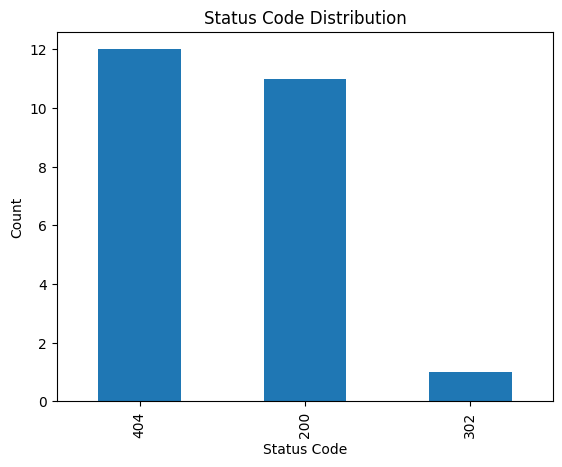

In [7]:
import matplotlib.pyplot as plt

status_counts.plot(kind='bar')
plt.title("Status Code Distribution")
plt.xlabel("Status Code")
plt.ylabel("Count")
plt.show()

In [17]:
ip_counts = df['IP'].value_counts()

# Threshold (you can adjust, e.g., >5 requests)
high_traffic_ips = ip_counts[ip_counts > 5]
print("High Traffic IPs:\n", high_traffic_ips)

High Traffic IPs:
 IP
::1    13
Name: count, dtype: int64


In [19]:
failed_403 = df[df['Status'] == '403']
failed_403_ips = failed_403['IP'].value_counts()

print("403 Attempts:\n", failed_403_ips)

403 Attempts:
 Series([], Name: count, dtype: int64)


In [20]:
failed_404 = df[df['Status'] == '404']
failed_404_ips = failed_404['IP'].value_counts()

print("404 Attempts:\n", failed_404_ips)

404 Attempts:
 IP
::1    2
Name: count, dtype: int64


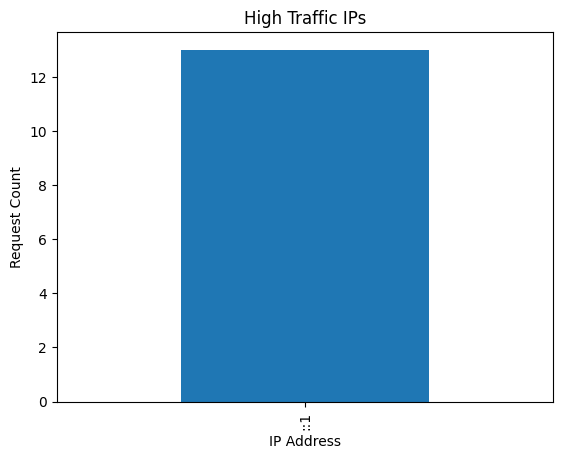

In [21]:
high_traffic_ips.plot(kind='bar')
plt.title("High Traffic IPs")
plt.xlabel("IP Address")
plt.ylabel("Request Count")
plt.show()

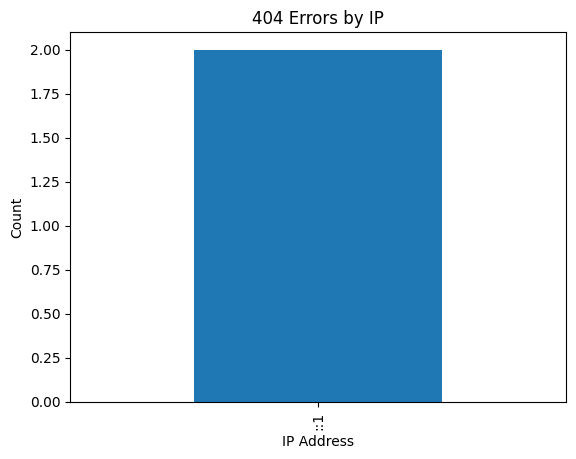

In [22]:
failed_404_ips.plot(kind='bar')
plt.title("404 Errors by IP")
plt.xlabel("IP Address")
plt.ylabel("Count")
plt.show()

In [23]:
most_active_ip = df['IP'].value_counts().idxmax()
print("Most Active IP:", most_active_ip)

suspicious_ips = set(high_traffic_ips.index) | set(failed_403_ips.index) | set(failed_404_ips.index)
print("Suspicious IPs:", suspicious_ips)

Most Active IP: ::1
Suspicious IPs: {'::1'}


In [24]:
for ip in suspicious_ips:
    print(f"\nIP: {ip}")
    
    if ip in high_traffic_ips:
        print(" - High Traffic")
    if ip in failed_403_ips.index:
        print(" - Repeated 403 (Unauthorized Access)")
    if ip in failed_404_ips.index:
        print(" - 404 Errors (Invalid Page Access)")


IP: ::1
 - High Traffic
 - 404 Errors (Invalid Page Access)
